# Tutorial 1 — From atmosphere to a corrected PSF

This notebook drives a minimal adaptive-optics loop with a pyturb atmosphere and checks the result against theory:

1. build a layered atmosphere (non-periodic `engine="extrude"`, since the run is long),
2. close a modal loop: a Zernike "DM" with a one-frame-delay integrator,
3. compare the residual with the fitting-error floor from `pyturb.theory`,
4. form the long-exposure PSF and compare its Strehl with the Maréchal approximation.

Everything runs on the CPU in well under a minute; pass `device="gpu"` to the atmosphere to move it to a GPU.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pyturb
from pyturb import analysis

D, n, wavelength = 8.0, 128, 1.65e-6          # 8 m pupil, H band
atm = pyturb.Atmosphere.from_profile("paranal-median", seeing=0.7, diameter=D, n=n,
                                     engine="extrude", seed=4)
print(atm)
print(f"r0 at {wavelength * 1e6:.2f} um: {atm.r0_at(wavelength):.2f} m")

Atmosphere(layers=9, r0=0.144 m, seeing=0.70", theta0=1.49", tau0=2.9 ms, n=128, diameter=8.0 m, device='cpu')
r0 at 1.65 um: 0.60 m


## A modal loop

The "deformable mirror" is the first 66 Zernike modes (radial orders up to 10). The wavefront sensor is ideal: it measures the residual's modal coefficients exactly, one frame late. An integrator with gain 0.5 updates the mirror. The atmosphere advances 1 ms per frame.

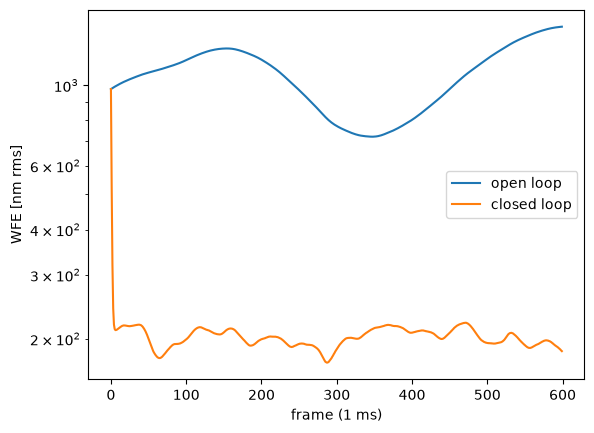

In [2]:
n_modes = 66
basis = analysis.zernike_basis(n_modes, n)
pupil = basis[0] != 0
B = basis[:, pupil]                            # (modes, pupil pixels)
reconstructor = np.linalg.pinv(B.T)            # residual phase -> modal coefficients

dt, steps, gain = 1e-3, 600, 0.5
command = np.zeros(n_modes)
measurement = np.zeros(n_modes)
open_rms, closed_rms, residuals = [], [], []
for k, (_t, opd) in enumerate(atm.frames(dt=dt, steps=steps,
                                         wavelength=wavelength)):
    phase = pyturb.to_numpy(opd)[pupil]        # rad at 1.65 um
    command += gain * measurement              # apply last frame's measurement
    residual = phase - command @ B
    measurement = reconstructor @ residual     # measured now, applied next frame
    open_rms.append(np.std(phase))
    closed_rms.append(np.std(residual))
    if k >= 100:                               # after convergence
        residuals.append(residual)

plt.figure()
plt.plot(np.array(open_rms) * wavelength / (2 * np.pi) * 1e9, label="open loop")
plt.plot(np.array(closed_rms) * wavelength / (2 * np.pi) * 1e9, label="closed loop")
plt.xlabel("frame (1 ms)")
plt.ylabel("WFE [nm rms]")
plt.yscale("log")
plt.legend()
plt.show()

## Against theory

With a perfect, instantaneous loop only the **fitting error** would remain: the power in modes beyond the first 66. For Kolmogorov turbulence that is Noll's residual `Δ_66 (D/r0)^{5/3}`. A finite outer scale (25 m here) removes mostly low-order power, which the DM corrects anyway, so it changes the fitting floor little. The **servo lag** of a one-frame delay adds to it.

In [3]:
r0 = atm.r0_at(wavelength)
measured = np.mean([np.var(r) for r in residuals])
fitting = analysis.noll_residual_variance(n_modes, D, r0)
print(f"measured closed-loop residual: {measured:.3f} rad^2")
print(f"Noll fitting-error floor:      {fitting:.3f} rad^2 (Kolmogorov)")
print(f"remainder (servo lag etc.):    {measured - fitting:.3f} rad^2")

measured closed-loop residual: 0.593 rad^2
Noll fitting-error floor:      0.578 rad^2 (Kolmogorov)
remainder (servo lag etc.):    0.015 rad^2


## Long-exposure PSF and Strehl

Average the instantaneous PSFs of the corrected residuals (2x padding), normalise by the diffraction-limited peak, and compare with the Maréchal approximation `exp(-σ²)`.

long-exposure Strehl 0.55, Marechal exp(-sigma^2) 0.55


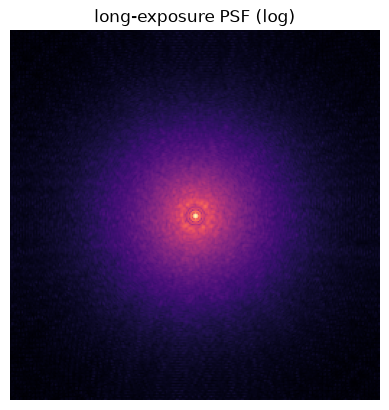

In [4]:
pad = 2 * n
field = np.zeros((n, n), complex)
psf = np.zeros((pad, pad))
for r in residuals[::5]:
    field[:] = 0
    field[pupil] = np.exp(1j * r)
    psf += np.abs(np.fft.fft2(field, s=(pad, pad))) ** 2
field[:] = 0
field[pupil] = 1.0
perfect = np.abs(np.fft.fft2(field, s=(pad, pad))) ** 2
strehl = psf.max() / len(residuals[::5]) / perfect.max()
print(f"long-exposure Strehl {strehl:.2f}, "
      f"Marechal exp(-sigma^2) {np.exp(-measured):.2f}")

plt.figure()
plt.imshow(np.log10(np.fft.fftshift(psf) / psf.max() + 1e-6), cmap="magma")
plt.title("long-exposure PSF (log)")
plt.axis("off")
plt.show()

## Where to go next

- `oversample=4` for faithful tip/tilt statistics on the spectral engine ([Choosing an engine](https://jacotay7.github.io/pyturb/engines/)).
- `pyturb.theory.zernike_temporal_psd` to predict the servo-lag error per mode.
- `pyturb.interop.HCIPyLayer` to replace the ideal sensor with an HCIPy optical model.